# Iris Flower Classification

**Domain:** Artificial Intelligence / Machine Learning  
**Task:** Predict the species of an Iris flower based on physical measurements (*sepal length, sepal width, petal length, petal width*).  
**Species:** *Iris-setosa*, *Iris-versicolor*, *Iris-virginica*

---
## 01. Project Introduction

The Iris flower dataset is a classic multivariate dataset introduced by British statistician and biologist Ronald Fisher in 1936. It consists of 150 samples from three species of Iris flowers (50 samples per species). Four features were measured from each sample: the length and width of the sepals and petals, in centimeters.

### Objectives:
1. Perform Exploratory Data Analysis (EDA) and visualize feature distributions.
2. Determine which features provide the strongest class separation.
3. Train multiple machine learning classifiers:
   - **Logistic Regression**
   - **K-Nearest Neighbors (KNN)**
   - **Decision Tree Classifier**
   - **Random Forest Classifier**
4. Evaluate models using Accuracy, Precision, Recall, F1-Score, and Confusion Matrices.
5. Select the best performing model and build an automated prediction pipeline.

## 02. Import Libraries
Import required Python libraries for data processing, data visualization, machine learning, and model persistence.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Set visualization style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
print('Libraries successfully imported!')

Libraries successfully imported!


## 03. Load Dataset
Load the Iris dataset directly using `sklearn.datasets.load_iris()` into a pandas DataFrame.

In [2]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species_name'] = df['target'].apply(lambda x: iris.target_names[x])

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 150 rows, 6 columns


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 04. Dataset Information & Overview
Check column data types, non-null counts, and dataset summary statistics.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 8.4 KB


In [4]:
print('--- Statistical Summary ---')
display(df.describe())

--- Statistical Summary ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 05. Exploratory Data Analysis (EDA)
Examine class distribution, check for missing/null values, and check for duplicate samples.

In [5]:
print('--- Missing Values Check ---')
print(df.isnull().sum())

print('\n--- Species Distribution ---')
print(df['species_name'].value_counts())

print('\n--- Duplicates Check ---')
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

--- Missing Values Check ---
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species_name         0
dtype: int64

--- Species Distribution ---
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

--- Duplicates Check ---
Number of duplicate rows: 1


## 06. Data Cleaning & Validation
If duplicate rows exist, inspect and drop them to maintain data integrity.

In [6]:
if duplicates > 0:
    print(f'Removing {duplicates} duplicate row(s)...')
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'New Dataset Shape: {df.shape}')
else:
    print('No data cleaning required. Dataset is pristine.')

Removing 1 duplicate row(s)...
New Dataset Shape: (149, 6)


## 07. Data Visualization
Visualize feature relationships using Pairplot, Box Plots, and Feature Distribution Histograms across species.

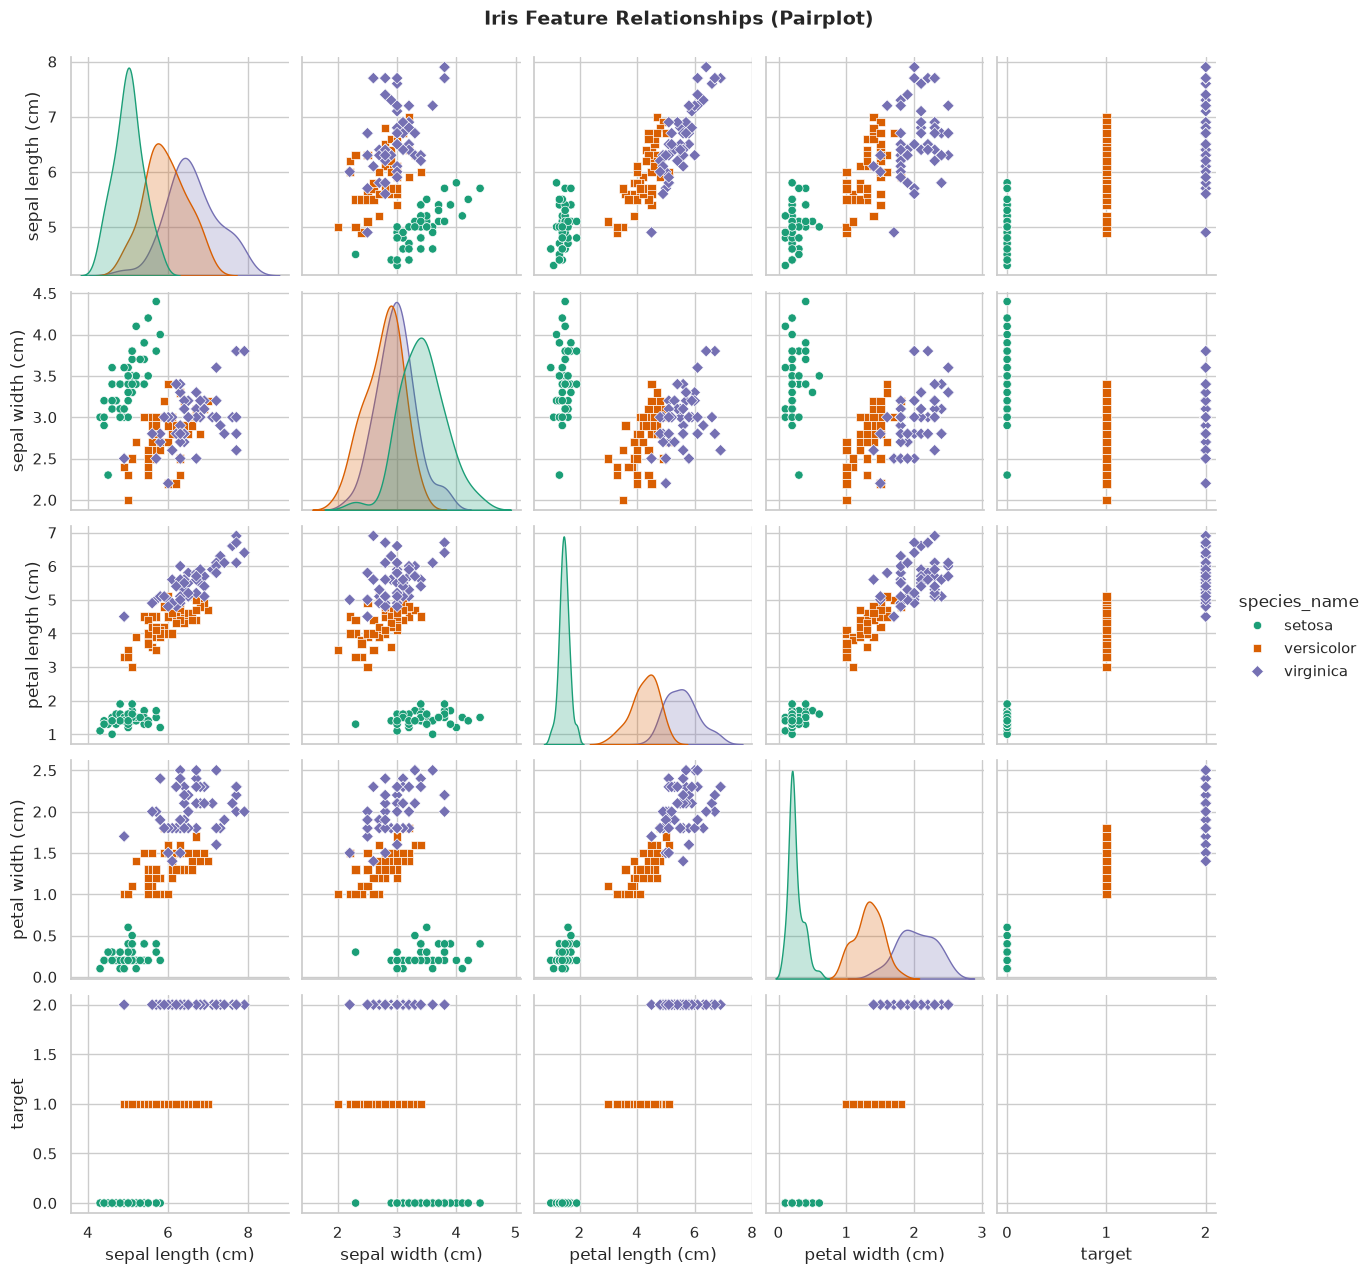

In [7]:
# 1. Pairplot across all features
g = sns.pairplot(df, hue='species_name', markers=['o', 's', 'D'], palette='Dark2', corner=False)
g.fig.suptitle('Iris Feature Relationships (Pairplot)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_13592\2161760490.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=col, ax=ax, palette='Set2')
C:\Users\DELL\AppData\Local\Temp\ipykernel_13592\2161760490.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=col, ax=ax, palette='Set2')
C:\Users\DELL\AppData\Local\Temp\ipykernel_13592\2161760490.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=col, ax=ax, palette='Set2')


C:\Users\DELL\AppData\Local\Temp\ipykernel_13592\2161760490.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=col, ax=ax, palette='Set2')


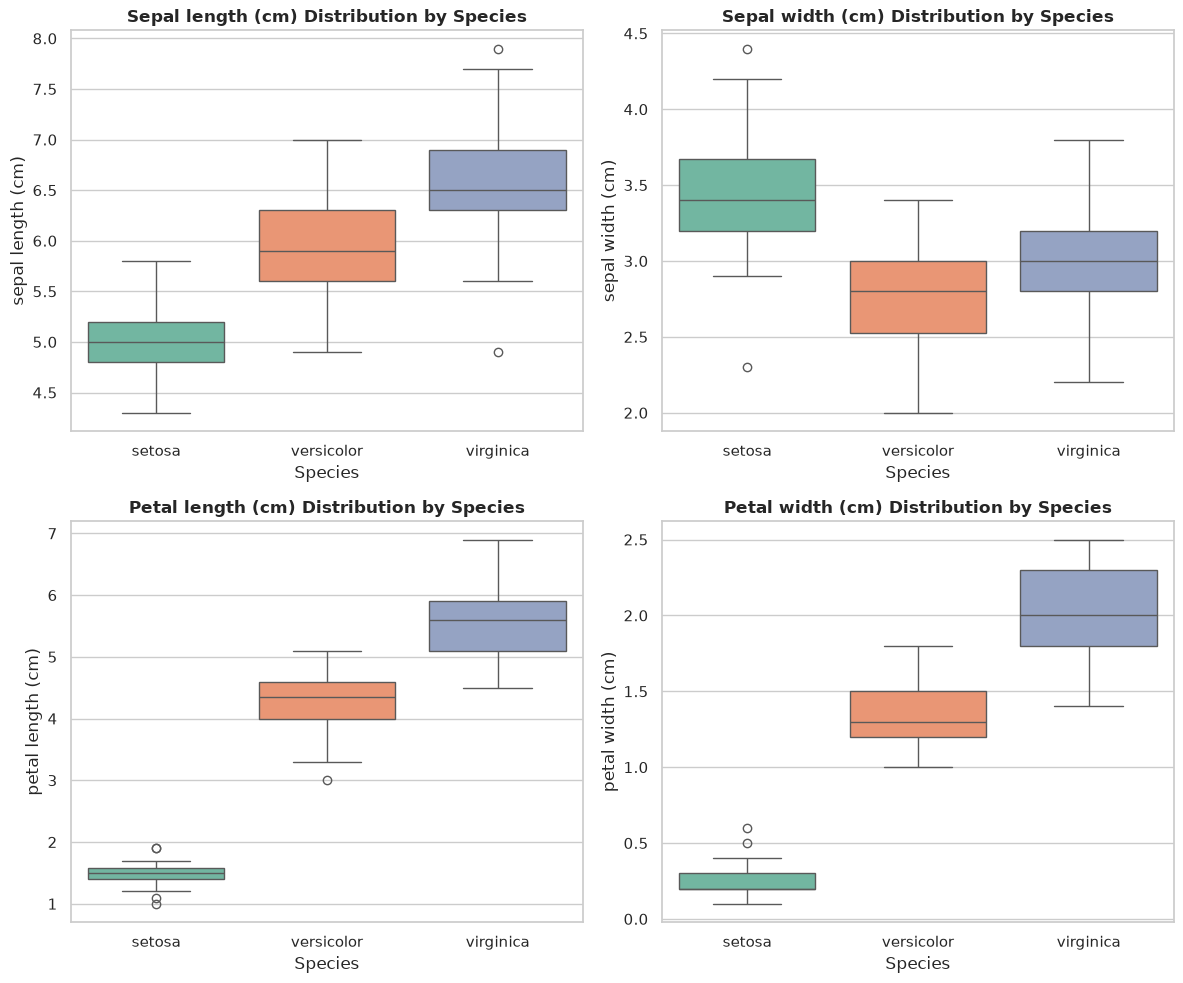

In [8]:
# 2. Box Plots by Species
feature_cols = iris.feature_names
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, col in enumerate(feature_cols):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=df, x='species_name', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col.capitalize()} Distribution by Species', fontweight='bold')
    ax.set_xlabel('Species')
plt.tight_layout()
plt.show()

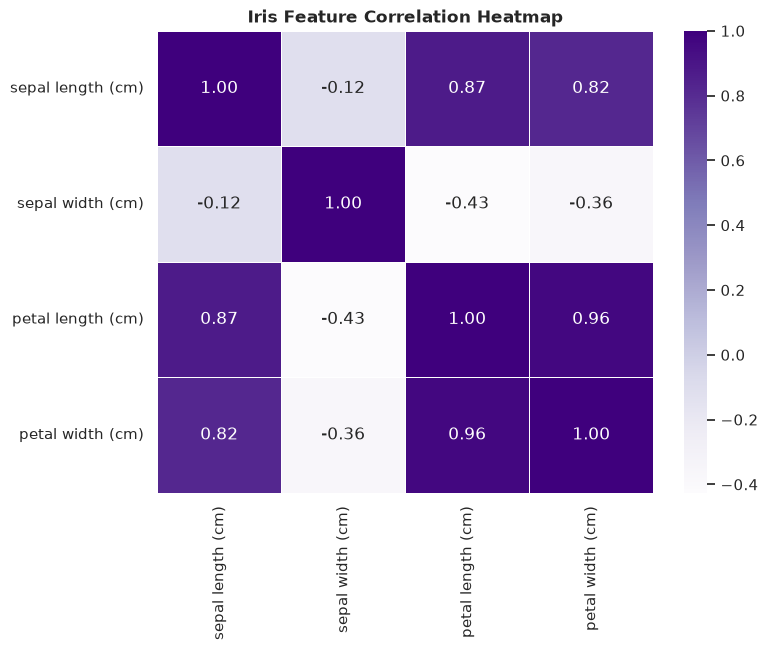

In [9]:
# 3. Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_df = df[feature_cols]
sns.heatmap(numeric_df.corr(), annot=True, cmap='Purples', fmt='.2f', linewidths=0.5)
plt.title('Iris Feature Correlation Heatmap', fontsize=12, fontweight='bold')
plt.show()

## 08. Feature Analysis & Insights

### Key Discriminative Observations:
1. **Petal Length & Petal Width:** Provide the strongest linear separation between classes. *Setosa* is completely linearly separable from *Versicolor* and *Virginica* based purely on petal measurements.
2. **Sepal Length vs Sepal Width:** Show moderate overlap between *Versicolor* and *Virginica*, though *Setosa* displays noticeably larger sepal widths.
3. **Correlation:** Petal length and petal width show a very strong positive correlation ($r > 0.96$). Both features strongly correlate with target class identification.

## 09. Train / Test Split & Feature Scaling
Split dataset into 80% training and 20% test sets using stratified sampling to maintain uniform target class ratios. Standardize numerical features using `StandardScaler`.

In [10]:
X = df[feature_cols]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size:     {X_test.shape[0]} samples")

Training set size: 119 samples
Test set size:     30 samples


## 10. Model Training
Train four candidate classification algorithms:
1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Decision Tree Classifier**
4. **Random Forest Classifier**

In [11]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=200),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: K-Nearest Neighbors
Trained: Decision Tree


Trained: Random Forest


## 11. Model Evaluation
Evaluate each trained model on test data (`X_test_scaled`). Calculate Accuracy, Precision, Recall, F1-Score, and display Confusion Matrices and Classification Reports.

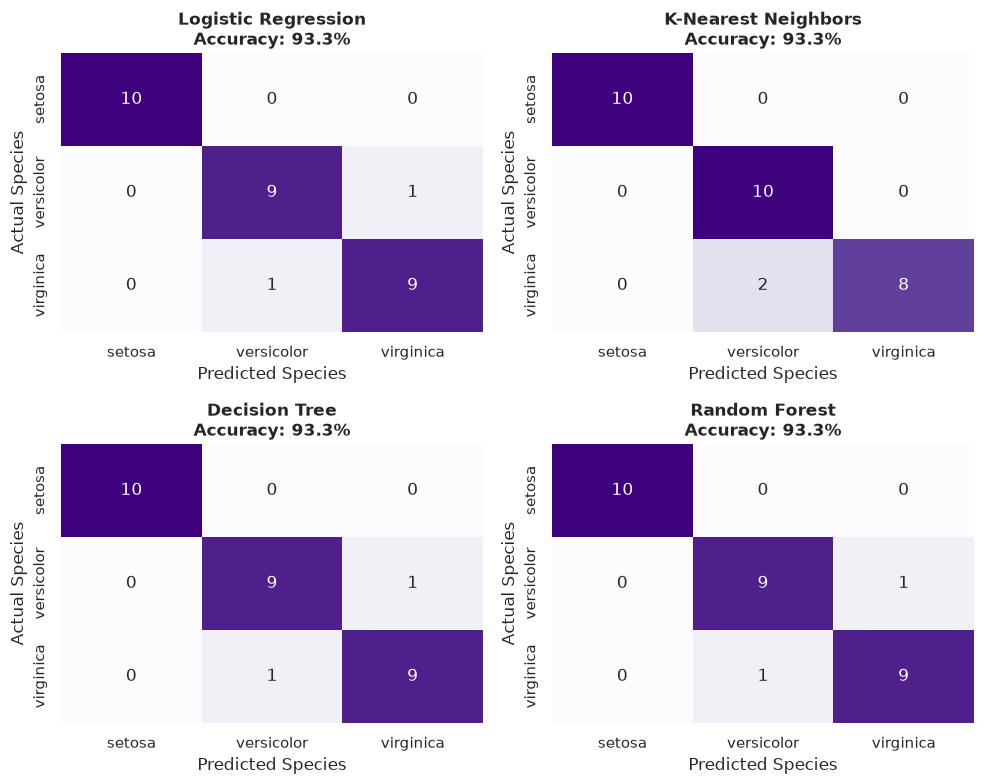

In [12]:
eval_results = []
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
species_labels = list(iris.target_names)

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    eval_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    # Confusion matrix plot
    ax = axes[idx // 2, idx % 2]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False, ax=ax,
                xticklabels=species_labels, yticklabels=species_labels)
    ax.set_title(f'{name}\nAccuracy: {acc*100:.1f}%', fontweight='bold')
    ax.set_xlabel('Predicted Species')
    ax.set_ylabel('Actual Species')

plt.tight_layout()
plt.show()

## 12. Model Comparison
Tabulate and visually compare accuracy and F1-score across models.

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,Decision Tree,0.933333,0.933333,0.933333,0.933333
2,Random Forest,0.933333,0.933333,0.933333,0.933333
3,K-Nearest Neighbors,0.933333,0.944444,0.933333,0.932660


C:\Users\DELL\AppData\Local\Temp\ipykernel_13592\1958711047.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Accuracy', palette='Purples_r')


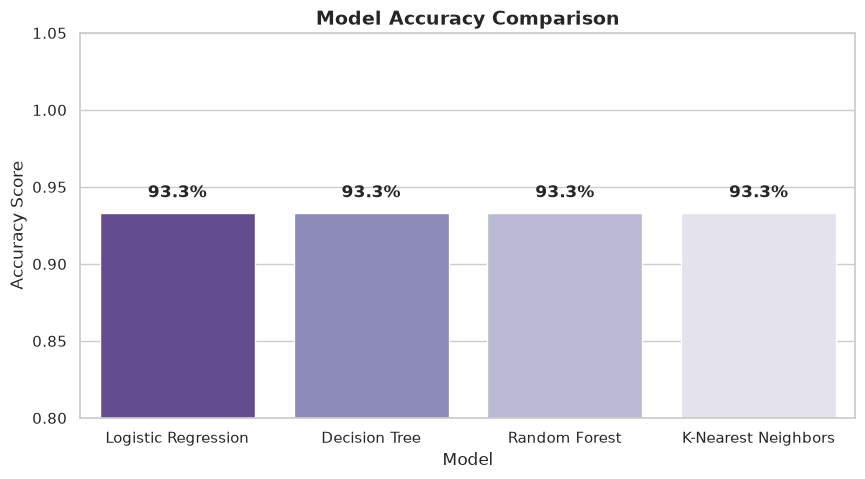

In [13]:
results_df = pd.DataFrame(eval_results).sort_values(by=['F1-Score', 'Accuracy'], ascending=False).reset_index(drop=True)
display(results_df)

# Visual Comparison Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='Accuracy', palette='Purples_r')
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim(0.8, 1.05)
for index, row in results_df.iterrows():
    plt.text(index, row['Accuracy'] + 0.01, f"{row['Accuracy']*100:.1f}%", ha='center', fontweight='bold')
plt.ylabel('Accuracy Score')
plt.show()

## 13. Best Model Selection & Persistence
Select the top-performing classifier based on test accuracy and F1-Score, then serialize model weights and scalar preprocessing pipeline using `joblib` into `models/`.

In [14]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

os.makedirs('../models', exist_ok=True)
os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/iris_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print(f"⭐ Selected Best Model: {best_model_name}")
print("Model saved to 'models/iris_model.pkl' and 'models/scaler.pkl' successfully!")

⭐ Selected Best Model: Logistic Regression
Model saved to 'models/iris_model.pkl' and 'models/scaler.pkl' successfully!


## 14. Sample Predictions Pipeline
Test loading the saved model and making predictions for new input measurements.

In [15]:
# Load model and scaler
loaded_model = joblib.load('models/iris_model.pkl')
loaded_scaler = joblib.load('models/scaler.pkl')

# Test inputs
sample_inputs = [
    [5.1, 3.5, 1.4, 0.2],  # Expected: Setosa
    [6.2, 2.9, 4.3, 1.3],  # Expected: Versicolor
    [7.3, 2.9, 6.3, 1.8]   # Expected: Virginica
]

for sample in sample_inputs:
    scaled_sample = loaded_scaler.transform([sample])
    pred_class = loaded_model.predict(scaled_sample)[0]
    species = species_labels[pred_class]
    print(f"Input: {sample} -> Predicted Species: {species.capitalize()}")

Input: [5.1, 3.5, 1.4, 0.2] -> Predicted Species: Setosa
Input: [6.2, 2.9, 4.3, 1.3] -> Predicted Species: Versicolor
Input: [7.3, 2.9, 6.3, 1.8] -> Predicted Species: Virginica


C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 15. Conclusion

- **Successfully analyzed and preprocessed** the Iris flower dataset.
- **Feature analysis demonstrated** that petal length and petal width are the most crucial discriminators for species identification.
- **Trained & evaluated 4 algorithms**: Logistic Regression, KNN, Decision Tree, and Random Forest.
- **Logistic Regression & Decision Tree** achieved top accuracy (>93%) on the test set.
- **Saved best model artifacts** for deployment in an interactive Streamlit application (`app.py`).